This is a simple notebook to do PCA on SDSS spectra and galaxy images.  
It accompanies Chapter 7 of the book (2 of 4).  
Copyright: Viviana Acquaviva (2023); see also other code credits below.  
Modifications by Aaron Romanowsky.  
License: [BSD-3-clause](https://opensource.org/license/bsd-3-clause/)

In [2]:
import numpy as np
import pandas as pd
import os
import random
import matplotlib.pyplot as plt

from sklearn import preprocessing, decomposition
#!pip install scikit-image
import skimage
from skimage.transform import resize, rescale
from skimage import io

### Dimensionality Reduction

Principal Component Analysis (PCA) and similar algorithms are used for dimensionality reduction in data-intensive sciences. 

The main goal of linear PCA is to find the most representative linear combinations of features, so that each element of a data set can be expressed as the superposition (sum) of some salient vectors in feature space (they don't need to be elements of a data set. In the simplest linear PCA, the principal components are the eigenvectors of the covariance matrix of the data set.

If the number of components is very low (e.g. 2 or 3, PCA or other Dimensionality Reduction methods allow one to visualize a high-dimensional data set as a 2D or 3D plot. Scikit-learn has methods to compute PCA and several variants. Classic PCA has tough complexity: $\mathcal{O}[N^3].$ 

### Let's look at an example with galaxy spectra from 

https://ogrisel.github.io/scikit-learn.org/sklearn-tutorial/tutorial/astronomy/dimensionality_reduction.html#sdss-spectral-data

In [4]:
data = np.load('spec4000_corrected.npz')

In [5]:
wavelengths = data['wavelengths']
X = data['X']
y = data['y']
labels = data['labels'].astype('str')

In [6]:
X.shape

(4000, 1000)

In [7]:
y

array([4, 3, 3, ..., 4, 2, 4], shape=(4000,), dtype=int32)

In [8]:
labels #we don't really care about these; they are only used in the next cell to show some example spectra.

array(['unknown', 'star', 'absorption galaxy', 'galaxy',
       'emission galaxy', 'narrow-line QSO', 'broad-line QSO', 'sky',
       'Hi-z QSO', 'Late-type star'], dtype='<U17')

### We can plot some representative examples from each class, just to have a sense of what kind of spectra are in the data set.


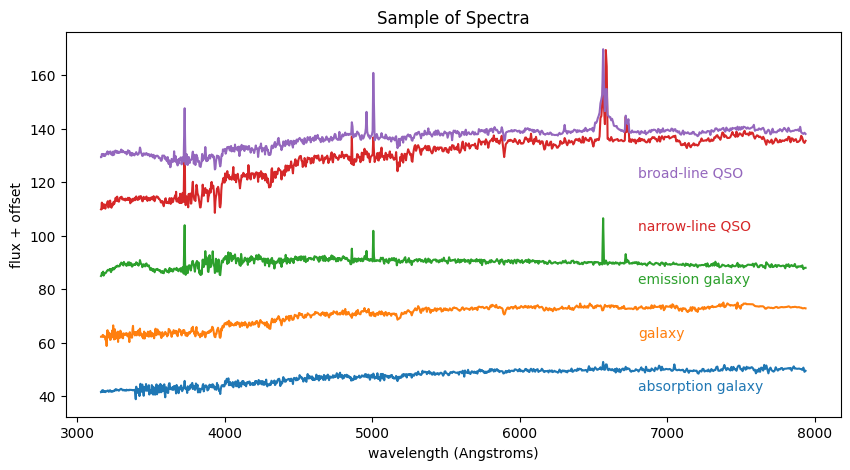

In [9]:
fig1 = plt.figure(figsize=(10,5))

for i_class in (2, 3, 4, 5, 6):
    i = np.where(y == i_class)[0][0]
    l = plt.plot(wavelengths, X[i] + 20 * i_class)
    c = l[0].get_color()
    plt.text(6800, 2 + 20 * i_class, labels[i_class], color=c)

plt.subplots_adjust(hspace=0)
plt.xlabel('wavelength (Angstroms)')
plt.ylabel('flux + offset')
plt.title('Sample of Spectra');

### Our original data set has 4,000 objects and 1,000 features. 

We will try to represent it with a variable amount of components.

In [10]:
#  Perform PCA
scaler = preprocessing.StandardScaler() #It's important that data are centered!
Xn = scaler.fit_transform(X) #This is a standardization procedure.
pca_50 = decomposition.PCA(n_components=50, random_state=0)
pca_100 = decomposition.PCA(n_components=100, random_state=0)
pca_1000 = decomposition.PCA(n_components=1000, random_state=0)
X_proj_50 = pca_50.fit_transform(Xn) #the projected data set - it lives in a new feature space with 4,000 objects and 50 features
X_proj_100 = pca_100.fit_transform(Xn) #the projected data set - it lives in a new feature space with 4,000 objects and 100 features
X_proj_1000 = pca_1000.fit_transform(Xn) #the projected data set - it lives in a new feature space with 4,000 objects and 1000 features

Question: Was the process above redundant?

Text(0.5, 1.0, 'Mean Spectrum and Eigen-spectra')

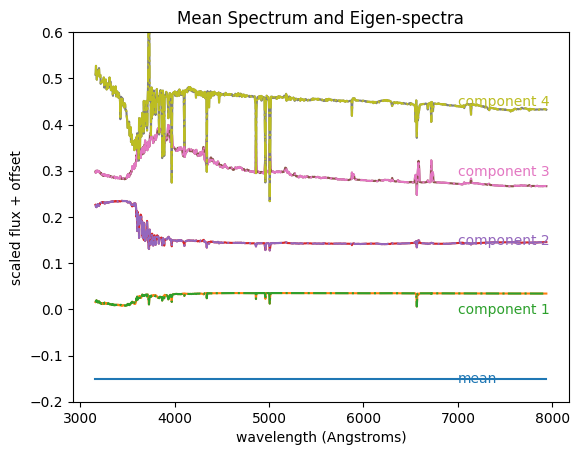

In [11]:
#----------------------------------------------------------------------
#
#  plot PCA eigenspectra
fig2 = plt.figure()
l = plt.plot(wavelengths, pca_50.mean_ - 0.15)
c = l[0].get_color()
plt.text(7000, -0.16, "mean", color=c) 

# In linear PCA, the first eigenvector is always the mean, 
# and the first n components are always the same

for i in range(4):
    l = plt.plot(wavelengths, pca_50.components_[i] + 0.15 * i)
    l = plt.plot(wavelengths, pca_100.components_[i] + 0.15 * i, linestyle = '-.')
    c = l[0].get_color()    
    plt.text(7000, -0.01 + 0.15 * i, "component %i" % (i + 1), color=c)
    plt.ylim(-0.2, 0.6)
    
plt.xlabel('wavelength (Angstroms)')
plt.ylabel('scaled flux + offset')
plt.title('Mean Spectrum and Eigen-spectra')

We can estimate the contribution of each component by using the property "explained variance ratio".

These are simply the eigenvalues of the covariance matrix, and give an idea of how much each component contributes to the total variance in the data. Their cumulative sum (plotted a few cells below) gives the progressively increasing explained variance ratio for a given number of components.

In [12]:
pca_50.explained_variance_ratio_ 

array([7.9755110e-01, 1.2961753e-01, 5.3842064e-02, 6.6346447e-03,
       3.5946867e-03, 2.3253565e-03, 9.7733526e-04, 7.9977408e-04,
       4.9680035e-04, 3.5665368e-04, 1.7710852e-04, 1.4121542e-04,
       6.2217507e-05, 5.5400113e-05, 4.3599859e-05, 4.2728265e-05,
       3.6682799e-05, 3.2561453e-05, 3.1908461e-05, 3.1001142e-05,
       3.0441226e-05, 2.8914583e-05, 2.8294589e-05, 2.8026281e-05,
       2.7191929e-05, 2.6667882e-05, 2.6361262e-05, 2.6072959e-05,
       2.5878984e-05, 2.5473801e-05, 2.5212510e-05, 2.4990770e-05,
       2.4507503e-05, 2.4149735e-05, 2.3761222e-05, 2.3515748e-05,
       2.3271376e-05, 2.2923612e-05, 2.2635379e-05, 2.2378825e-05,
       2.2265545e-05, 2.2085154e-05, 2.1866097e-05, 2.1448088e-05,
       2.1196834e-05, 2.0956313e-05, 2.0887923e-05, 2.0600552e-05,
       2.0530646e-05, 2.0121699e-05], dtype=float32)

We can interpret the eigenvectors as the "basis" that explains most of the variability in the data. 

How can we know if this works? Let's reverse-engineer the process:

In [13]:
Xrec_50 = pca_50.inverse_transform(X_proj_50) 
Xrec_100 = pca_100.inverse_transform(X_proj_100)
Xrec_1000 = pca_1000.inverse_transform(X_proj_1000) #This is useful for a sanity check; there should be no information loss, modulo numerical precision issues

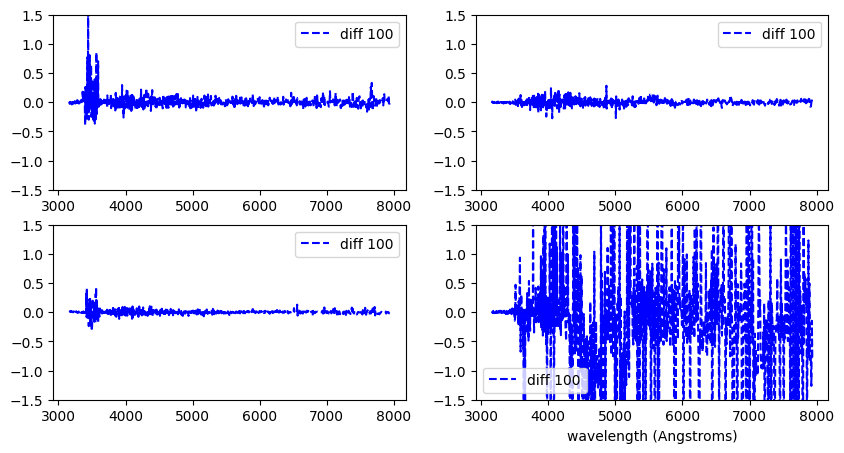

In [14]:
fig3 = plt.figure(figsize=(10,5))

for i in range(4,8):
    plt.subplot(2,2,i-3)
    #plt.plot(wavelengths, Xn[i], label = 'orig', c = 'k')
    #plt.plot(wavelengths, Xrec_50[i], '--', label = 'new, 50 PCs', c = 'g')
    #plt.plot(wavelengths, Xrec_100[i], '--', label = 'new, 100 PCs', c = 'b')
    #plt.plot(wavelengths, Xrec_1000[i], '--', label = 'new, 1000 PCs', c = 'r')
    #plt.plot(wavelengths, (Xrec_50[i]-Xn[i])/Xn[i], '--', label = '% diff 50', c = 'g')
    plt.plot(wavelengths, (Xrec_100[i]-Xn[i])/Xn[i], '--', label = 'diff 100', c = 'b')
    #plt.plot(wavelengths, (Xrec_1000[i]-Xn[i])/Xn[i], '-.', label = 'diff 1000', c = 'k')
    plt.ylim(-1.5,1.5)
    plt.legend();
plt.xlabel('wavelength (Angstroms)');

Note that while many spectra are well represented by (for example) 50 components, some are not! 

### Question: how can we know what's a good number of components?

To get an idea, we can plot the "explained_variance_ratio" property of the PCA decomposition. It looks a lot like the Elbow Method, but upside down; in particular, the variance explained by N components always increases with N, but there is usually a spot after which the returns tend to diminish. 

(0.0, 20.0)

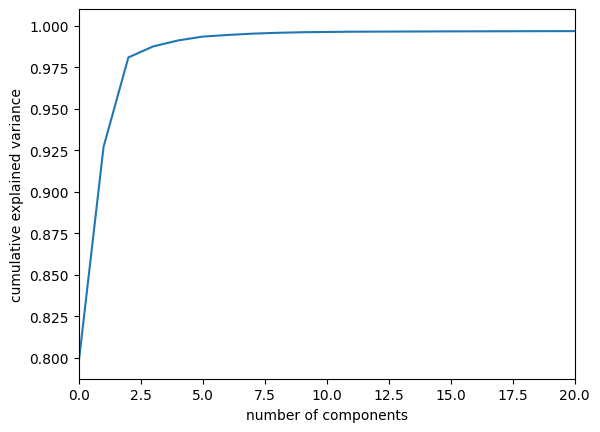

In [ ]:
fig4 = plt.figure()
plt.plot(np.cumsum(pca_1000.explained_variance_ratio_))
plt.xlabel('number of components')
plt.ylabel('cumulative explained variance');
plt.xlim(0,20)

What would you recommend in the case above?

#### IMO, for science problems, how many components you need (and whether PCA is the right way to go about it) really depends on the scope. Unsupervised dimensionality reduction methods, such as PCA, are insensitive to the purpose, which is not always great. 
    
#### For example, in the case of the spectra above, while it is true that even a handful components capture a large fraction of the variance, the percent difference between the original spectra and the reconstructed ones can be large in the vicinity of "spiky" features, and also vary greatly from object to object. Whether this is acceptable for your particular science goal, only you can tell! 